In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Calculating acceleration and graphing

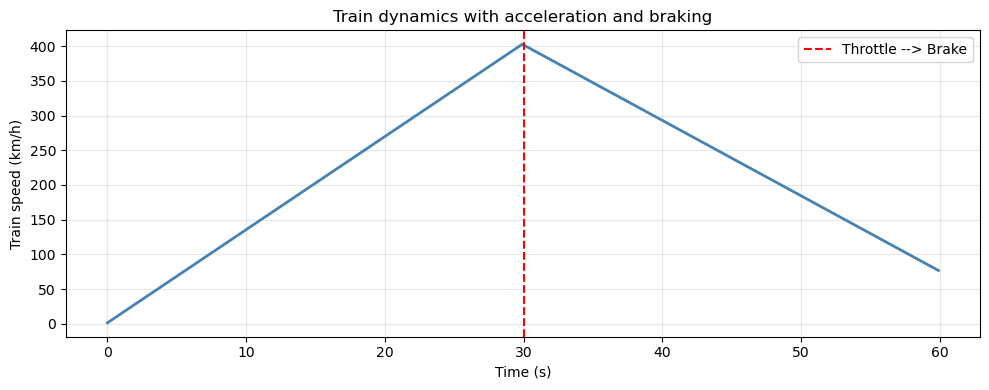

In [2]:
MASS = 4e4
MAX_TRACTION = 15e4
MAX_BRAKE = 12e4
ROLLING_RES = 2e-3
# seconds per timestep
DT = 0.1

def train_acceleration(v, throttle, brake, gradient_deg=0):

    #the component of the gravitational force which is parallel to the gradient
    f_slope = -MASS * 9.81 * np.sin(np.radians(gradient_deg))
    
    #force that comes from the brakes
    f_brake = -brake * MAX_BRAKE

    #the resistive force that comes from the tires of the train.
    f_rolling_res = -ROLLING_RES * MASS * 9.81

    f_traction = MAX_TRACTION * throttle

    f_net = f_slope + f_brake + f_rolling_res + f_traction

    #F_net = mass * acceleration
    return f_net / MASS

#60 seconds of simulation
steps = 600
#velocity of the train, initially zero
velocity = 0.0
#the speeds to be plotted
speeds = []

#divides the steps into equal parts, from 0 to 59.9, 0.0,0.1....
times = np.arange(steps) * DT

for i, t in enumerate(times):

    #train accelerates in the first 30 seconds then starts to use the brakes
    throttle = 1.0 if t < 30 else 0.0
    brake = 0.0 if t < 30 else 1.0

    a = train_acceleration(velocity, throttle, brake)
    
    #calculating the velocity from the formula: v_final = v_initial + a*t
    velocity = max(0.0, velocity + a * DT)

    # m/s -> km/h
    speeds.append(velocity * 3.6)

#size of the plot
plt.figure(figsize=(10,4))

#the x,y variables;line color and width
plt.plot(times, speeds, color="steelblue", linewidth=2)

#drawing the point the train starts decelearting
plt.axvline(30, color="red", linestyle="--", label="Throttle --> Brake")
plt.xlabel("Time (s)")
plt.ylabel("Train speed (km/h)")
plt.title("Train dynamics with acceleration and braking")

#showing the gridlines
plt.grid(True,alpha=0.3)

#
plt.legend()
plt.tight_layout()
plt.show()

### Graphing with different gradients

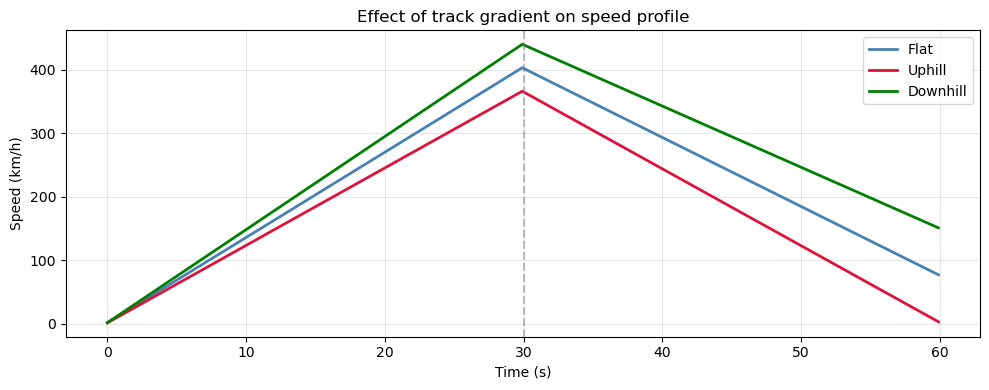

In [3]:
fig, ax = plt.subplots(figsize=(10,4))

for grad, label, color in [(0, "Flat", "steelblue"),
                           (2,"Uphill", "crimson"),
                           (-2,"Downhill","green")]:

    velocity = 0.0
    speeds = []

    for t in times:

        throttle = 1.0 if t < 30 else 0.0
        brake = 0.0 if t < 30 else 1.0

        a = train_acceleration(velocity, throttle, brake, grad)
        velocity = max(0.0, velocity + a * DT)
        speeds.append(velocity * 3.6)

    ax.plot(times, speeds, label=label, color=color, linewidth=2)

ax.axvline(30, color="gray", linestyle='--', alpha=0.5)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Speed (km/h)")
ax.set_title("Effect of track gradient on speed profile")
ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()
plt.show()
    


### Graphing position and velocity graphs

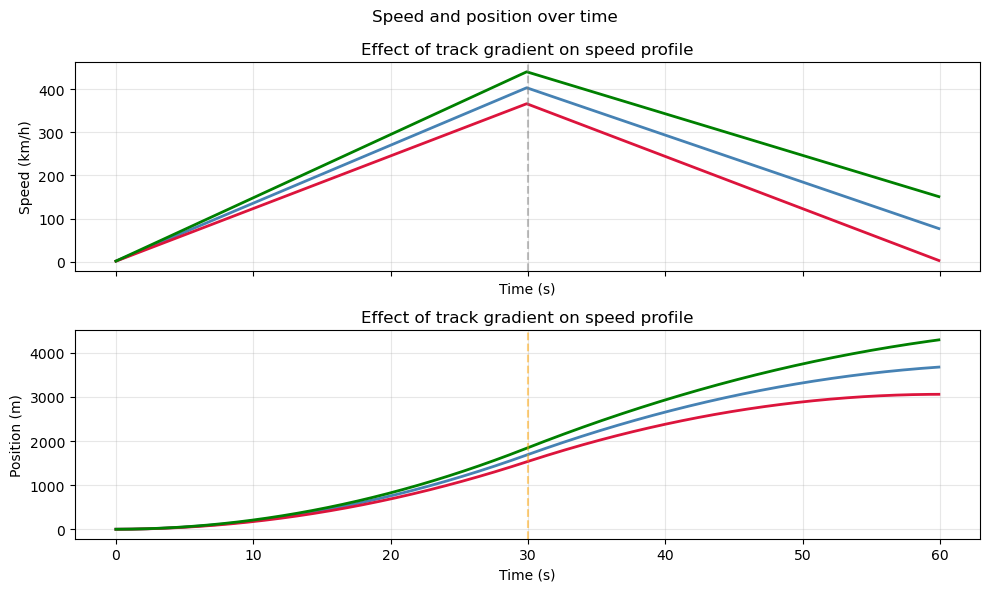

In [4]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

for grad, label, color in [(0, "Flat", "steelblue"),
                           (2,"Uphill", "crimson"),
                           (-2,"Downhill","green")]:

    velocity = 0.0
    position = 0.0
    
    speeds, positions = [], []
    
    for t in times:
    
        throttle = 1.0 if t < 30 else 0.0
        brake = 0.0 if t < 30 else 1.0
    
        a = train_acceleration(velocity, throttle, brake, grad)
        
        velocity = max(0.0, velocity + a * DT)
        position = position + velocity * DT
        
        speeds.append(velocity * 3.6)
        positions.append(position)

    ax1.plot(times, speeds, label=label, color=color, linewidth=2)
    ax2.plot(times, positions, label=label, color=color, linewidth=2)

ax1.axvline(30, color="gray", linestyle='--', alpha=0.5)
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Speed (km/h)")
ax1.set_title("Effect of track gradient on speed profile")
ax1.grid(True, alpha=0.3)

ax2.axvline(30, color="orange", linestyle='--', alpha=0.5)
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Position (m)")
ax2.set_title("Effect of track gradient on speed profile")
ax2.grid(True, alpha=0.3)

plt.suptitle("Speed and position over time")
plt.tight_layout()
plt.show()




### PID Controller Notes

If we use ON/OFF control, the room temperature for example will fluctuate around the target value, which is not ideal for industries.

PID : Proportional, Integral, Derivative

Error = Setpoint - process_variable

Proportional: deals with the instantaneous error. (K_p*e(t))


Integral: the error that accumulates over time. (integral of K_i*dt between zero to t). this will prevent the offset that might appear in a P controller


Derivative: analyzes the rate of change of the error and reacts accordingly, dampening rapid changes

Output error: proportional_error + integral_error + derivative_error

Based on this error, the train will react as a throttle or break>

In [5]:

import matplotlib.gridspec as gridspec
from scipy import signal as sp_signal

In [6]:
class PID_Controller():

    def __init__(self,KP,KI,KD,output_limit=1.0, integral_limit=50.0):

        self.kp, self.ki, self.kd = KP, KI, KD
        #max reaction limit(?)
        self.output_limit = output_limit
        #max integral accumulation limit(??)
        self.integral_limit = integral_limit

        #for calculating and accumulating the integral error
        self.integral = 0.0
        #for calculating the derrivative error
        self.prev_error = 0.0
        #inital error value (?)
        self.initialized = 0.0
        
    def reset(self):

        self.integral = 0.0
        self.prev_error = 0.0
        self.initialized = False
    
    def compute(self,target_speed, current_speed, dt):

        error = target_speed - current_speed

        #accumulating error over time, the I part of the PID controller
        self.integral += error * dt
        self.integral = np.clip(self.integral, -self.integral_limit, self.integral_limit)
        
        proportional_error = self.kp * error

        if not self.initialized:

            #the derivative starts from zero, 
            #the rate of change of the error in the beginning is zero.
            derivative = 0.0
            self.initialized = True
        else:

            derivative = (error - self.prev_error)/dt

        self.prev_error = error

        output = self.kp * error + self.ki * self.integral + self.kd * derivative
        return float(np.clip(output, -self.output_limit, self.output_limit))
        
def convert_to_brake_or_throttle(pid_output):

    """
    Has to either throttle or brake. Cannot do them both simultaneously.
    """
    if pid_output >= 0:

        return pid_output, 0.0

    return 0.0, abs(pid_output)

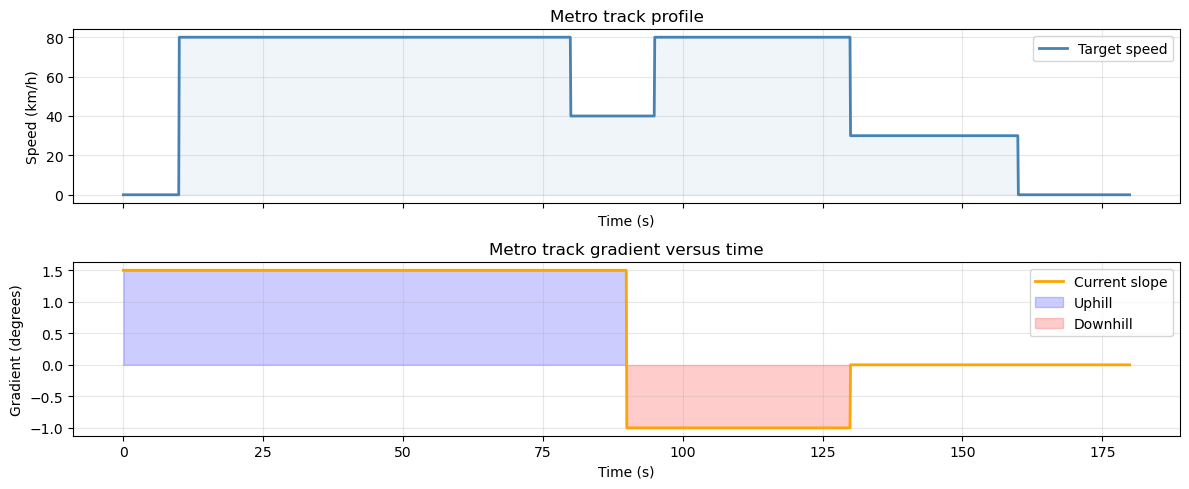

Track profile saved.


In [7]:
TOTAL_TIME = 180
#an array of time stamps divided into .1 lengths.
times = np.arange(0,TOTAL_TIME,DT)

def get_target_speed(t):

    """
    Speed profile for a metro inter-station run.
    Returns target speed in km/h at time t (seconds).

    Station A ──► accelerate ──► cruise ──► slow zone ──► cruise ──► brake ──► Station B
    """

    if   t <  10:  return  0    # standing at Station A
    elif t <  40:  return 80    # accelerate to 80 km/h line speed
    elif t <  80:  return 80    # cruise at 80 km/h
    elif t <  95:  return 40    # speed restriction zone (40 km/h)
    elif t < 130:  return 80    # resume line speed
    elif t < 160:  return 30    # braking approach to Station B
    else:          return  0    # stopped at Station B

def get_gradient(t):

    if 0 <= t < 90:

        return 1.5

    elif 90 <= t < 130:

        return -1.0

    return 0

target_speeds = [get_target_speed(t) for t in times]
gradients = [get_gradient(t) for t in times]

fig, (ax1, ax2) = plt.subplots(2,1, figsize=(12,5), sharex=True)

ax1.plot(times, target_speeds, color="steelblue", linewidth=2, label="Target speed")
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Speed (km/h)")
ax1.set_title("Metro track profile")
ax1.legend()
ax1.grid(True,alpha=0.3)
ax1.fill_between(times, target_speeds, alpha=0.08, color="steelblue")

ax2.plot(times, gradients, color="orange", linewidth=2, label="Current slope")
ax2.fill_between(times, gradients, 0, where=[g > 0 for g in gradients], 
                 alpha=0.2,color="blue",label="Uphill")
ax2.fill_between(times, gradients, 0, where=[g < 0 for g in gradients], 
                 alpha=0.2, color='red', label= 'Downhill')
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Gradient (degrees)")
ax2.set_title("Metro track gradient versus time")
ax2.legend()
ax2.grid(True, alpha=0.3)


plt.tight_layout()
plt.savefig('week2_track_profile.png', dpi=150, bbox_inches='tight')
plt.show()
print('Track profile saved.')

In [8]:
MASS = 4e4
MAX_TRACTION = 15e4
MAX_BRAKE = 12e4
ROLLING_RES = 2e-3
DT = 0.1
def run_simulation(kp,ki,kd,label="Simulation"):

    pid = PID_Controller(KP=kp,KI=ki,KD=kd)
    pid.reset()

    velocity = 0.0
    position = 0.0

    log = {
        'time' : [],
        'speed_actual' : [],
        'speed_target' : [],
        'speed_error' : [],
        'throttle' : [],
        'brake' : [],
        'position' : [],
        'gradient' : [],
        'pid_output' : [],
        'label' : label,
        'kp' : kp,
        'ki' : ki,
        'kd' : kd
        }

    for t in times:

        target_speed = get_target_speed(t)
        gradient = get_gradient(t)
        log['time'].append(t)
        log['gradient'].append(gradient)
        log['speed_target'].append(target_speed)

        current_speed = velocity * 3.6
        
        pid_out = pid.compute(target_speed, current_speed, DT)
        throttle, brake = convert_to_brake_or_throttle(pid_out)
        

        a = train_acceleration(velocity, throttle, brake, gradient)
        velocity = max(0.0, velocity + a*DT)
        position += velocity * DT

        log['speed_error'].append(target_speed - current_speed)
        log['speed_actual'].append(current_speed)
        log['throttle'].append(throttle)
        log['brake'].append(brake)
        log['position'].append(position)
        log['pid_output'].append(pid_out)

    for key in log:

        if isinstance(log[key], list) and key !='label':

            log[key] = np.array(log[key])

    return log

result = run_simulation(kp=0.8, ki=0.05, kd=1.5, label='Tuned PID')

print(f'Simulation complete.')
#final value of the position: total distance
print(f'Total distance: {result["position"][-1]:.0f} m')
print(f'Max speed error: {np.abs(result["speed_error"]).max():.1f} km/h')
print(f'Mean speed error (cruise only): '
      f'{np.abs(result["speed_error"][400:800]).mean():.2f} km/h')        

Simulation complete.
Total distance: 2933 m
Max speed error: 80.0 km/h
Mean speed error (cruise only): 4.54 km/h


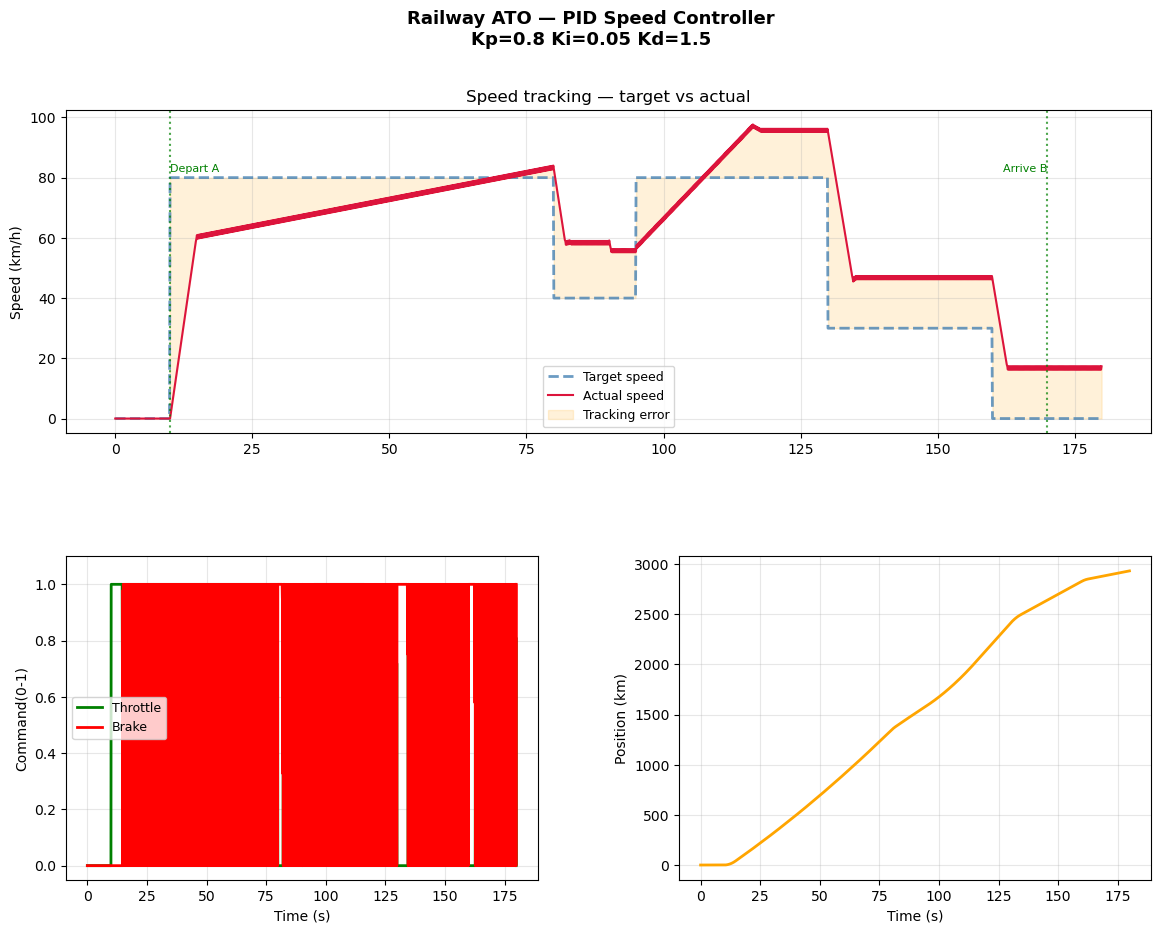

Simulation plot saved.


In [19]:
def plot_simulation(log, title='ATO Simulation'):

    fig = plt.figure(figsize=(14,10))
    fig.suptitle(
        f"{title}\nKp={log['kp']} Ki={log['ki']} Kd={log['kd']}", fontsize=13, fontweight="bold")

    gs = gridspec.GridSpec(2,2, figure=fig, hspace=0.38, wspace=0.3)

    #first row, spans all the columns
    ax1 = fig.add_subplot(gs[0,:])
    
    #plotting the actual and target speed lines
    ax1.plot(log['time'],log['speed_target'], color='steelblue', linewidth=2, linestyle='--',
             label="Target speed", alpha=0.8)
    ax1.plot(log['time'], log['speed_actual'], color='crimson',
             linewidth=1.5, label="Actual speed")

    #filling the difference with a color, ki error (?)
    ax1.fill_between(log['time'],log['speed_actual'],log['speed_target'],alpha=0.15,color='orange'
                     ,label='Tracking error')
    
    ax1.set_ylabel('Speed (km/h)', fontsize=10)
    ax1.set_title('Speed tracking — target vs actual')
    ax1.legend(fontsize=9)
    ax1.grid(True, alpha=0.3)

    #the time it departs from A and the time it arrives at B 
    #(theoretically it should end with 0km/h)
    ax1.axvline(10,color='green',linestyle=':', alpha=0.7)
    ax1.axvline(170,color='green', linestyle=':', alpha=0.7)
    
    #label the vertical lines
    ax1.text(10,  82, 'Depart A', fontsize=8, color='green')
    ax1.text(162, 82, 'Arrive B', fontsize=8, color='green')

    
    ax2 = fig.add_subplot(gs[1,0])
    ax2.plot(log['time'], log['throttle'], color='green', linewidth=2,label="Throttle")
    ax2.plot(log['time'], log['brake'], color='red', linewidth=2, label='Brake')
    ax2.set_xlabel("Time (s)")
    ax2.set_ylabel("Command(0-1)")
    ax2.set_ylim(-0.05,1.1)
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3)

    ax3 = fig.add_subplot(gs[1,1])
    ax3.plot(log['time'], log['position'], color='orange', linewidth=2, label='Position')
    ax3.set_xlabel('Time (s)', fontsize=10)
    ax3.set_ylabel('Position (km)', fontsize=10)
    ax3.grid(True, alpha=0.3)

    plt.savefig('week2_simulation.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Simulation plot saved.')

plot_simulation(result, title='Railway ATO — PID Speed Controller')


#indicate the points on 3rd graph where it starts to use the brakes maybe.
    

In [20]:
import json

with open("train_motion.ipynb") as f:
    nb = json.load(f)

lines = sum(
    len(cell["source"])
    for cell in nb["cells"]
    if cell["cell_type"] == "code"
)
print(f"Lines of code: {lines}")

Lines of code: 408


## Testting different values of PID constants

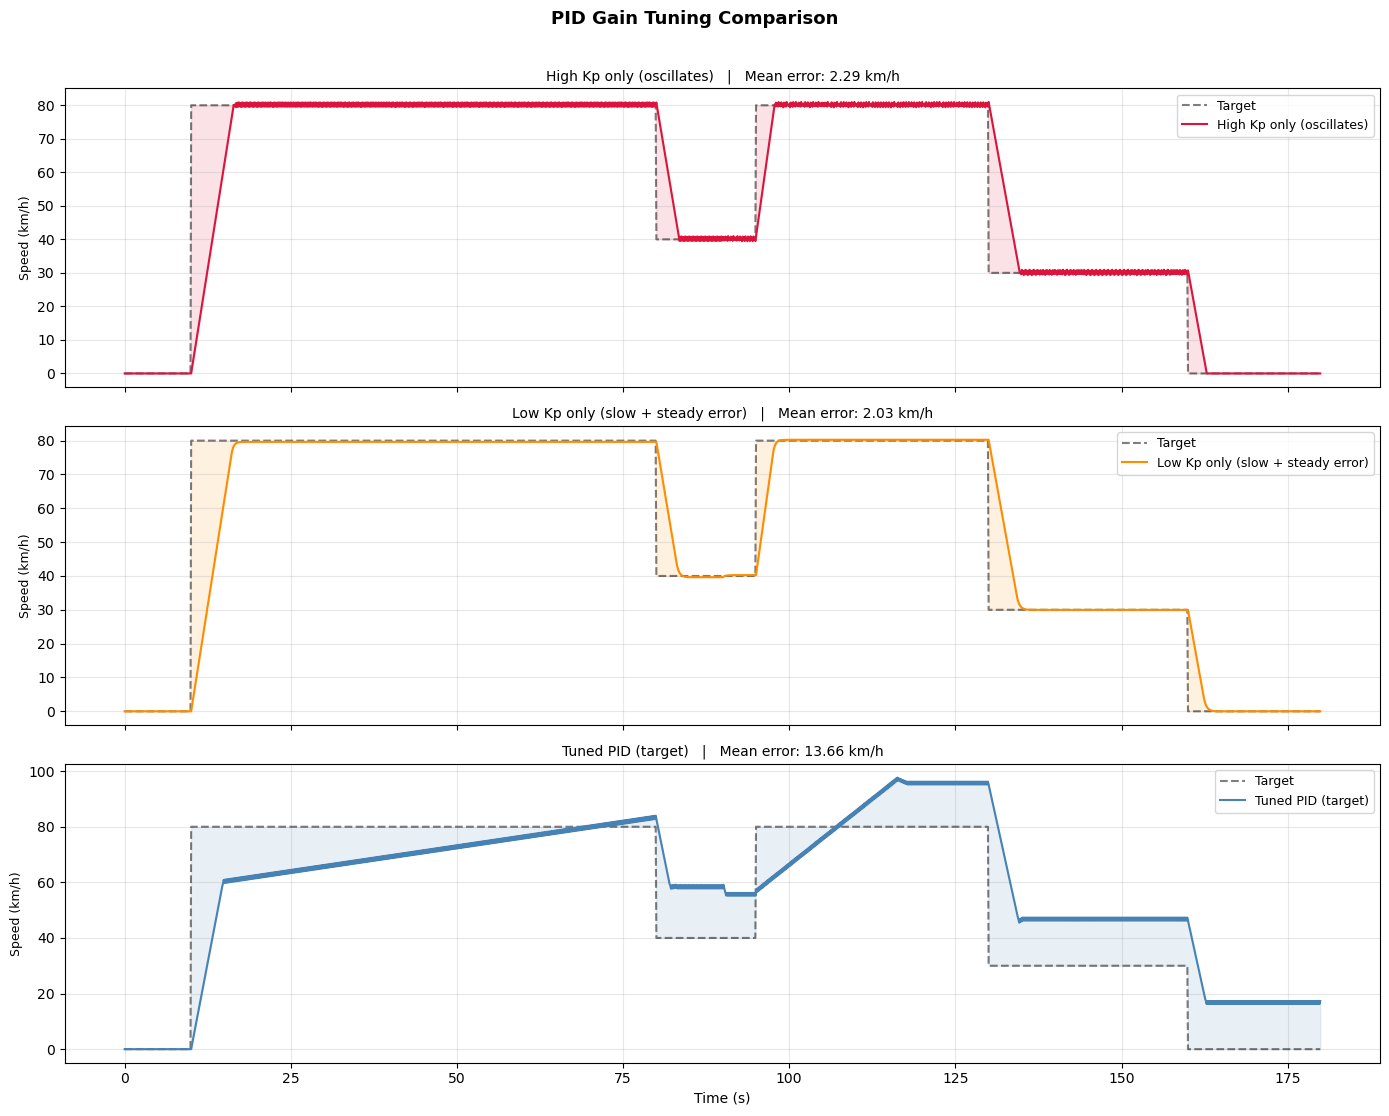

Tuning comparison saved.

High Kp only (oscillates)                 MAE: 2.29 km/h
Low Kp only (slow + steady error)         MAE: 2.03 km/h
Tuned PID (target)                        MAE: 13.66 km/h


In [21]:
configs = [
    dict(kp=2.5,  ki=0.0,  kd=0.0,  label='High Kp only (oscillates)'),
    dict(kp=0.2,  ki=0.0,  kd=0.0,  label='Low Kp only (slow + steady error)'),
    dict(kp=0.8,  ki=0.05, kd=1.5,  label='Tuned PID (target)'),
]

#treat each key-value as a parameter
results = [run_simulation(**cfg) for cfg in configs]

# Plot comparison
fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)
colors = ['crimson', 'darkorange', 'steelblue']

for ax, res, color in zip(axes, results, colors):
    ax.plot(res['time'], res['speed_target'], 'k--',
            linewidth=1.5, alpha=0.5, label='Target')
    ax.plot(res['time'], res['speed_actual'], color=color,
            linewidth=1.5, label=res['label'])
    ax.fill_between(res['time'],
                    res['speed_target'],
                    res['speed_actual'],
                    alpha=0.12, color=color)
    ax.set_ylabel('Speed (km/h)', fontsize=9)
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(True, alpha=0.3)
    mae = np.abs(res['speed_error'][200:]).mean()
    ax.set_title(f"{res['label']}   |   Mean error: {mae:.2f} km/h", fontsize=10)

axes[-1].set_xlabel('Time (s)', fontsize=10)
fig.suptitle('PID Gain Tuning Comparison', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('week2_tuning_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('Tuning comparison saved.')
print()
for res in results:
    mae = np.abs(res['speed_error'][200:]).mean()
    print(f"{res['label']:<40}  MAE: {mae:.2f} km/h")

In [24]:
import json

with open("train_motion.ipynb") as f:
    nb = json.load(f)

lines = sum(
    len(cell["source"])
    for cell in nb["cells"]
    if cell["cell_type"] == "code"
)
print(f"Lines of code: {lines}")

Lines of code: 447
